# Project Overview: Health Outcomes of Horses

**Objective:** Predict the clinical health status and survival outcomes of horses based on veterinary indicators, physiological signals, and synthetic data dynamics.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s3e22')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s3e22


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import warnings
warnings.filterwarnings('ignore')

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e22/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e22/test.csv')

In [4]:
train_df.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,...,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,...,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,...,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,...,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,...,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


In [5]:
test_df.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,1235,no,adult,534053,38.6,40.0,20.0,normal,normal,normal_pink,...,distend_small,42.0,7.5,clear,2.3,no,0,0,0,no
1,1236,yes,adult,528469,38.2,112.0,48.0,cool,reduced,bright_pink,...,distend_small,44.0,6.0,serosanguious,2.6,no,2208,0,0,yes
2,1237,yes,adult,528178,37.7,66.0,12.0,cool,normal,bright_red,...,distend_small,31.5,6.0,cloudy,1.6,yes,2205,0,0,yes
3,1238,no,adult,534784,37.1,88.0,20.0,cool,reduced,pale_cyanotic,...,distend_large,75.0,81.0,NaN,1.0,yes,1400,0,0,no
4,1239,yes,adult,529840,38.3,50.0,12.0,NaN,normal,bright_pink,...,distend_small,37.0,6.8,cloudy,2.6,yes,2208,0,0,yes


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1235 non-null   int64  
 1   surgery                1235 non-null   object 
 2   age                    1235 non-null   object 
 3   hospital_number        1235 non-null   int64  
 4   rectal_temp            1235 non-null   float64
 5   pulse                  1235 non-null   float64
 6   respiratory_rate       1235 non-null   float64
 7   temp_of_extremities    1196 non-null   object 
 8   peripheral_pulse       1175 non-null   object 
 9   mucous_membrane        1214 non-null   object 
 10  capillary_refill_time  1229 non-null   object 
 11  pain                   1191 non-null   object 
 12  peristalsis            1215 non-null   object 
 13  abdominal_distention   1212 non-null   object 
 14  nasogastric_tube       1155 non-null   object 
 15  naso

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     824 non-null    int64  
 1   surgery                824 non-null    object 
 2   age                    824 non-null    object 
 3   hospital_number        824 non-null    int64  
 4   rectal_temp            824 non-null    float64
 5   pulse                  824 non-null    float64
 6   respiratory_rate       824 non-null    float64
 7   temp_of_extremities    789 non-null    object 
 8   peripheral_pulse       777 non-null    object 
 9   mucous_membrane        811 non-null    object 
 10  capillary_refill_time  818 non-null    object 
 11  pain                   795 non-null    object 
 12  peristalsis            805 non-null    object 
 13  abdominal_distention   802 non-null    object 
 14  nasogastric_tube       760 non-null    object 
 15  nasoga

In [8]:
train_df.shape

(1235, 29)

In [9]:
test_df.shape

(824, 28)

In [10]:
train_df.isnull().sum()

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       39
peripheral_pulse          60
mucous_membrane           21
capillary_refill_time      6
pain                      44
peristalsis               20
abdominal_distention      23
nasogastric_tube          80
nasogastric_reflux        21
nasogastric_reflux_ph      0
rectal_exam_feces        190
abdomen                  213
packed_cell_volume         0
total_protein              0
abdomo_appearance         48
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
outcome                    0
dtype: int64

In [11]:
test_df.isnull().sum()

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       35
peripheral_pulse          47
mucous_membrane           13
capillary_refill_time      6
pain                      29
peristalsis               19
abdominal_distention      22
nasogastric_tube          64
nasogastric_reflux        14
nasogastric_reflux_ph      0
rectal_exam_feces        125
abdomen                  154
packed_cell_volume         0
total_protein              0
abdomo_appearance         31
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
dtype: int64

## 3. Exploratory Data Analysis

In [12]:
train_df['outcome'].value_counts(normalize=True)

outcome
lived         0.464777
died          0.331984
euthanized    0.203239
Name: proportion, dtype: float64

/tmp/ipykernel_56/2504683424.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='outcome', y=col, data=train_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_56/2504683424.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='outcome', y=col, data=train_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_56/2504683424.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='outcome', y=col, data=train_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_56/2504683424.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is depre

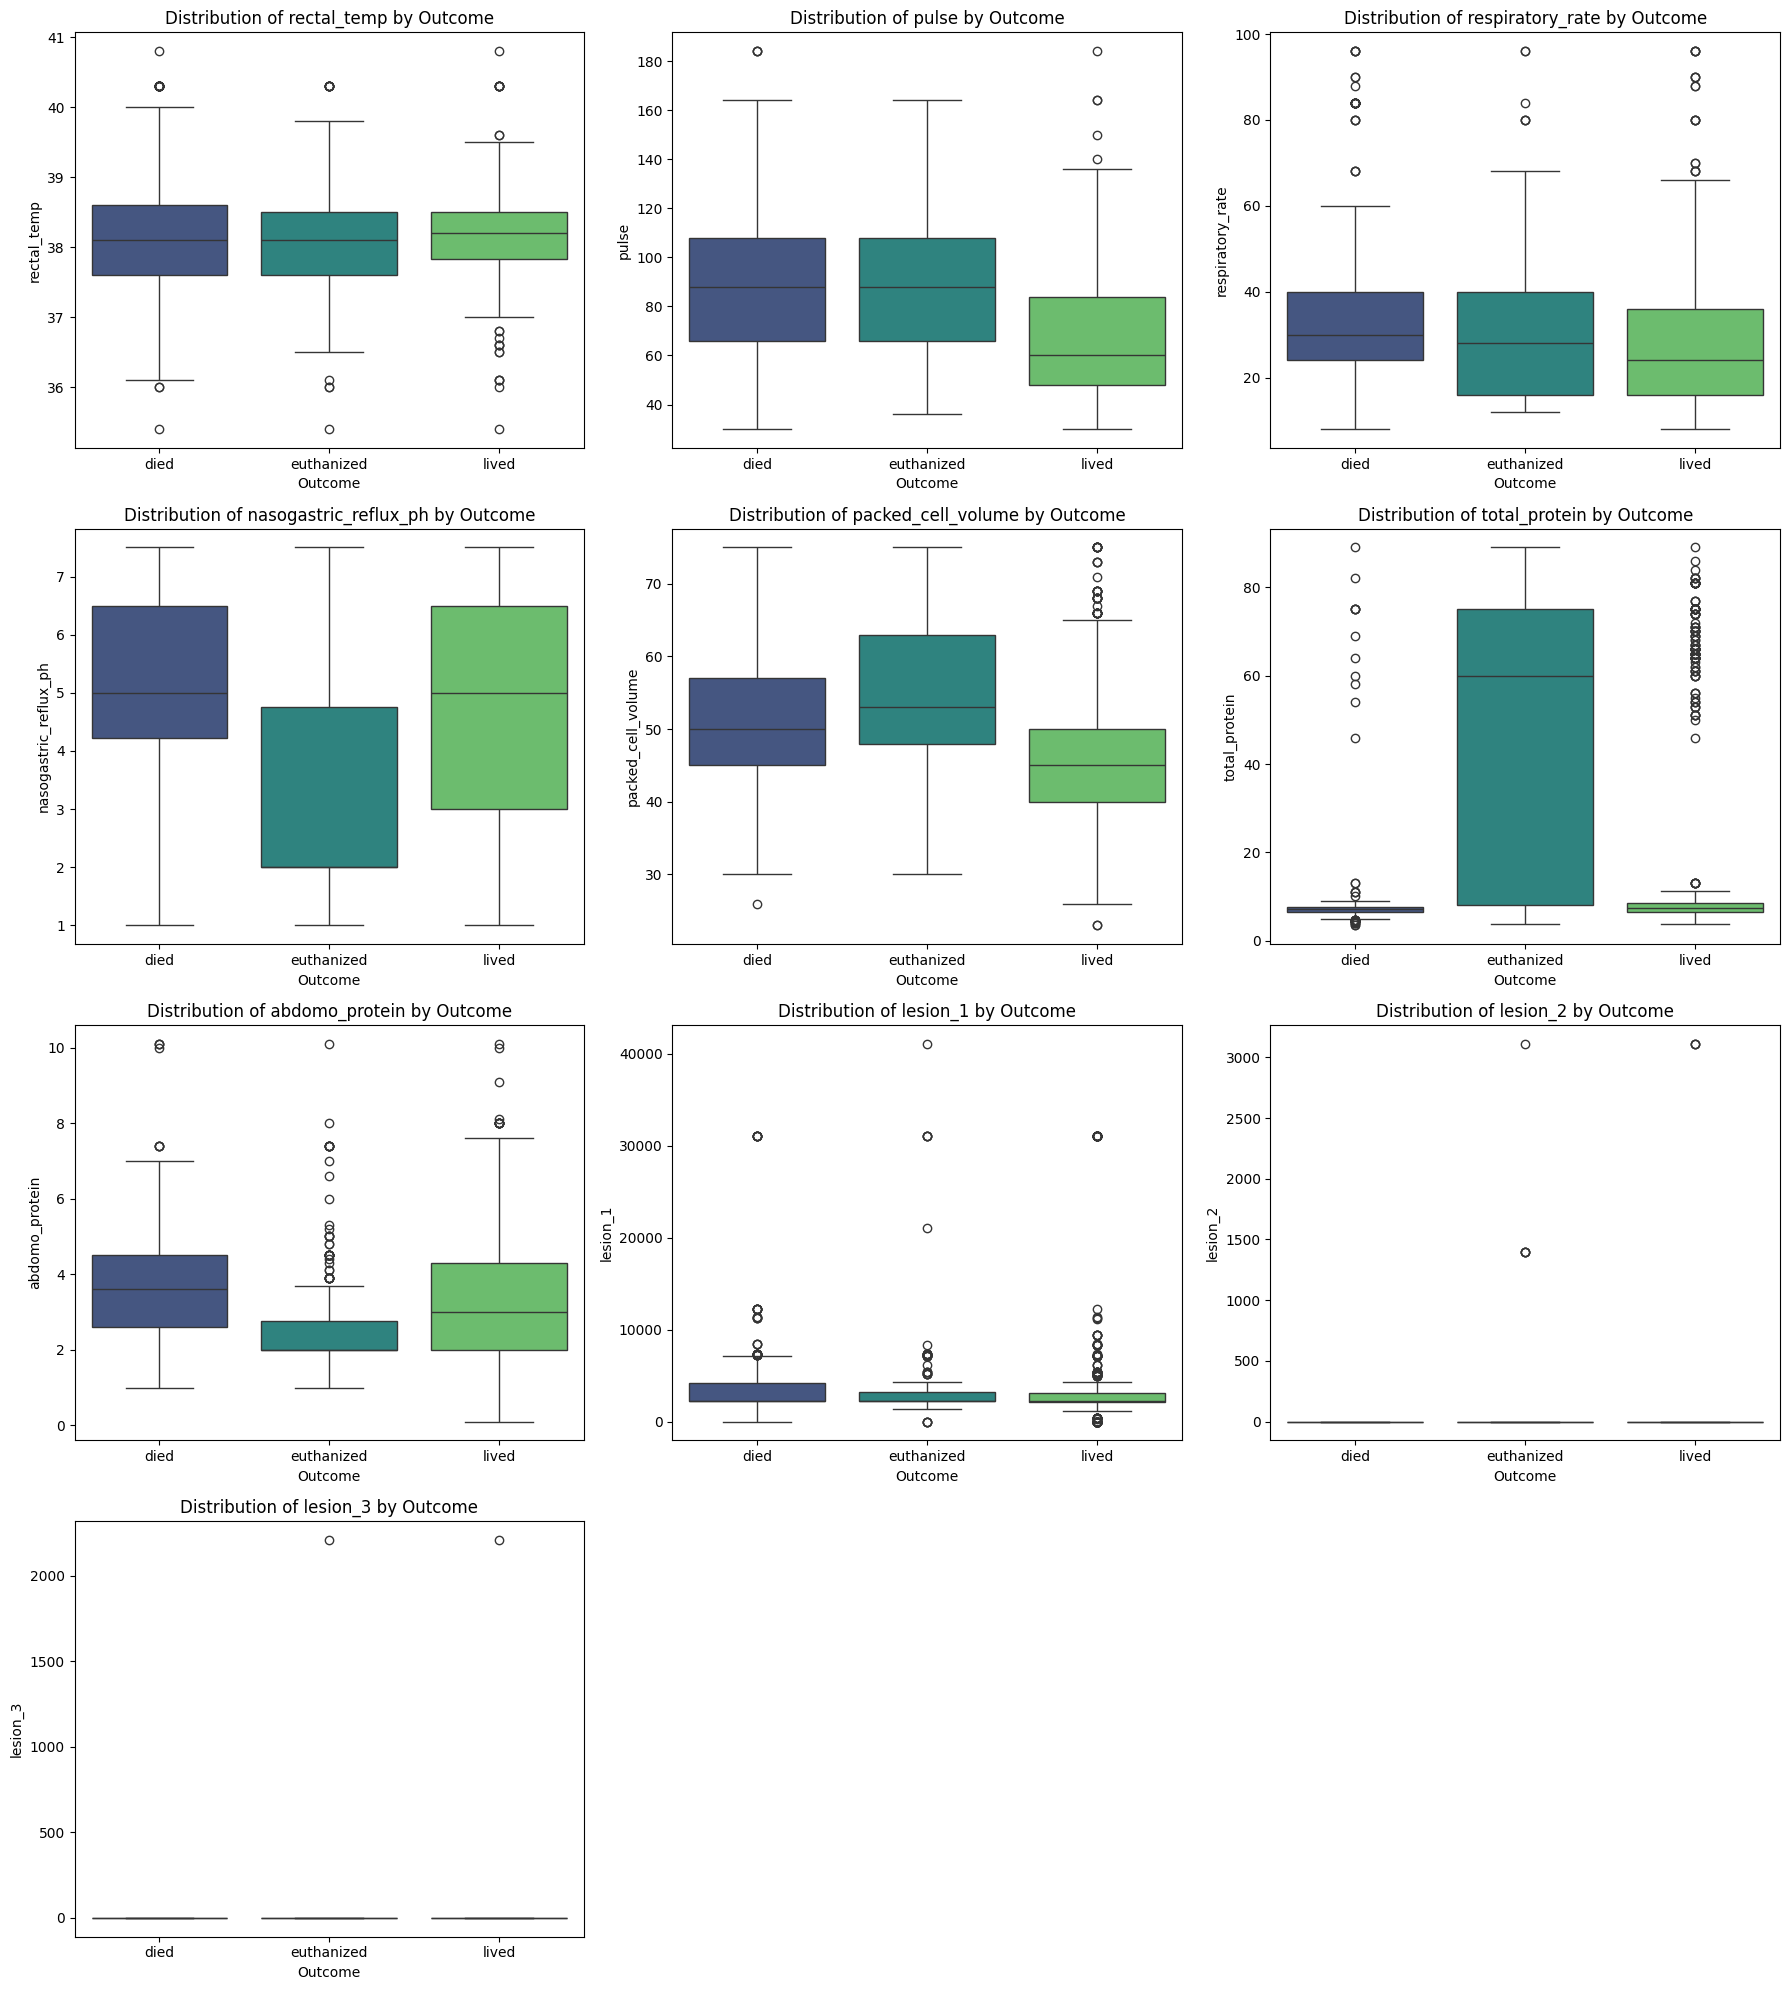

In [13]:
# Identify numerical columns (excluding ID or non-predictive columns if necessary)
numerical_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove 'id' or 'hospital_number' if they are not relevant for analysis
cols_to_exclude = ['id', 'hospital_number']
numerical_cols = [col for col in numerical_cols if col not in cols_to_exclude]

# Calculate grid dimensions for subplots
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

# Plotting
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='outcome', y=col, data=train_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col} by Outcome')
    axes[i].set_xlabel('Outcome')
    axes[i].set_ylabel(col)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

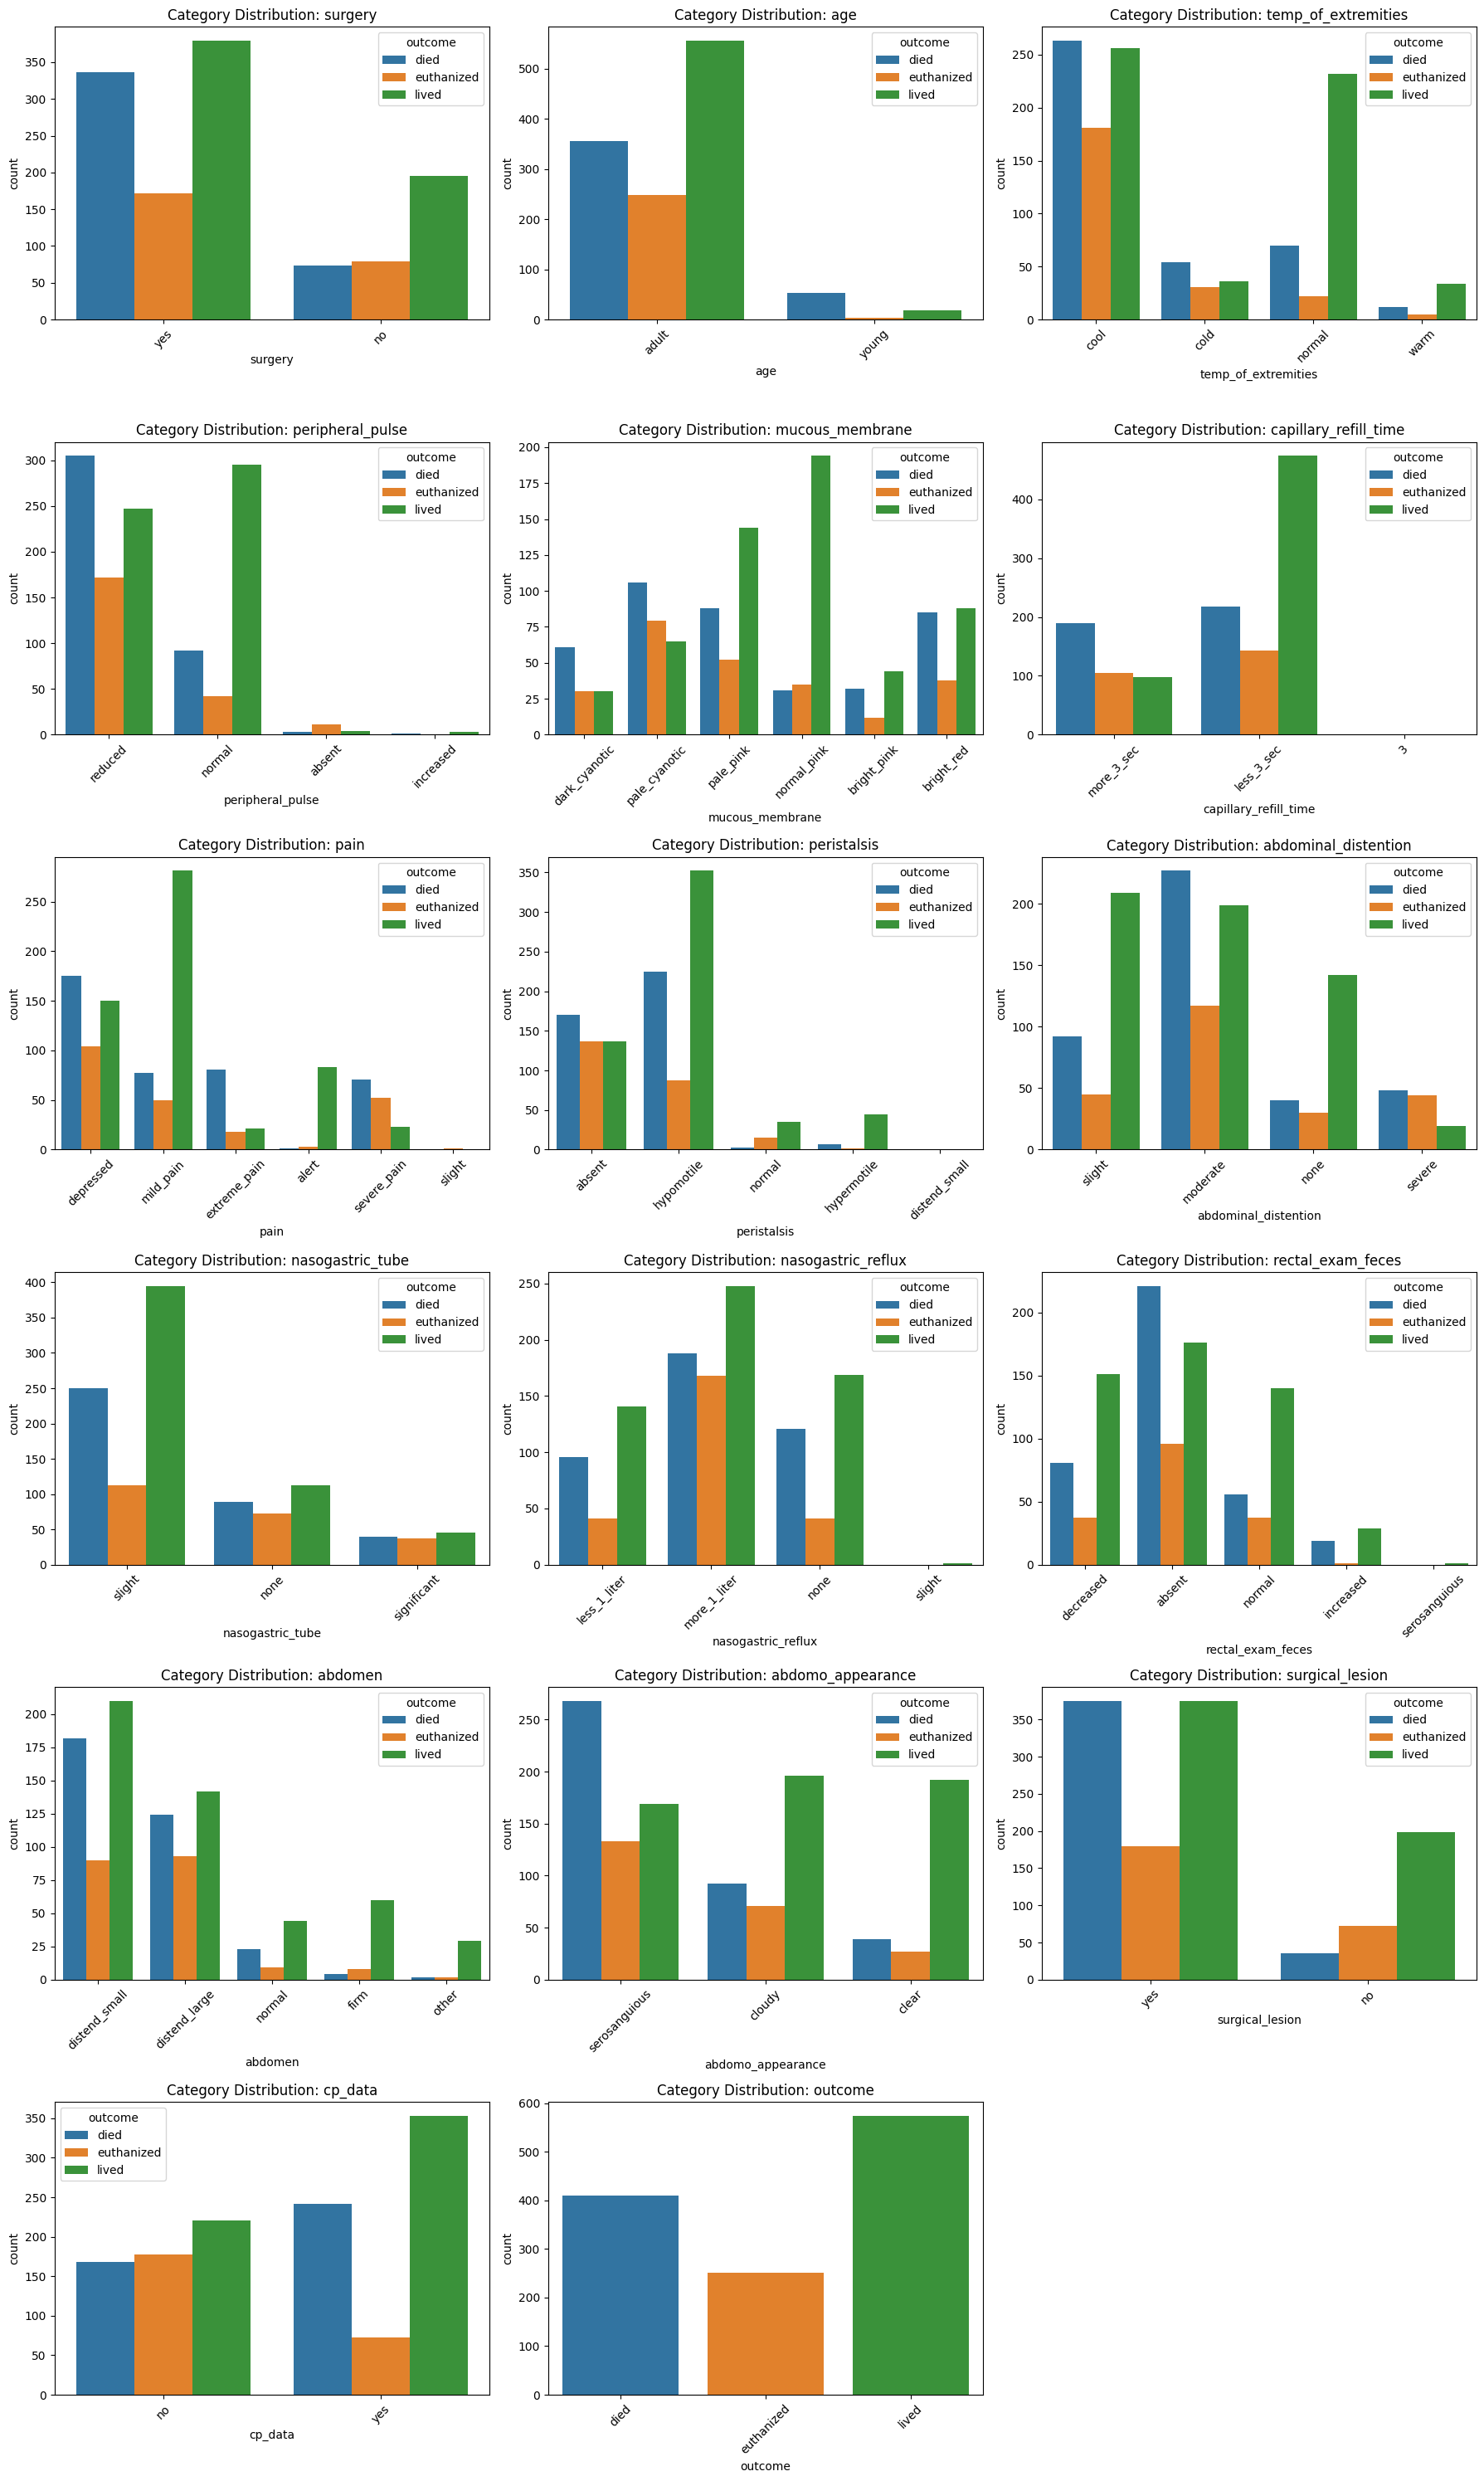

In [14]:
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='outcome', data=train_df, ax=axes[i])
    axes[i].set_title(f'Category Distribution: {col}')
    axes[i].tick_params(axis='x', rotation=45) # Etiketler birbirine girmesin diye döndürdük

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [15]:
categorical_columns = train_df.select_dtypes(include=['object']).columns

cols_to_clean = categorical_columns.drop('outcome')

for col in cols_to_clean:
    train_df[col] = train_df[col].fillna('Missing')

for col in cols_to_clean:
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna('Missing')

In [16]:
total_missing = train_df.isnull().sum().sum() + test_df.isnull().sum().sum()

In [17]:
total_missing

np.int64(0)

In [18]:
# Select categorical columns excluding 'outcome'
cat_cols = train_df.select_dtypes(include=['object']).columns.drop('outcome', errors='ignore')

# Print unique values for both train and test to compare them
for col in cat_cols:
    print(f"--- Column: {col} ---")
    train_uniques = train_df[col].unique()
    test_uniques = test_df[col].unique() if col in test_df.columns else "Not in test_df"
    
    print(f"Train unique values ({len(train_uniques)}): {train_uniques}")
    print(f"Test unique values  ({len(test_uniques) if isinstance(test_uniques, list) else 0}): {test_uniques}")
    print("-" * 30 + "\n")

--- Column: surgery ---
Train unique values (2): ['yes' 'no']
Test unique values  (0): ['no' 'yes']
------------------------------

--- Column: age ---
Train unique values (2): ['adult' 'young']
Test unique values  (0): ['adult' 'young']
------------------------------

--- Column: temp_of_extremities ---
Train unique values (5): ['cool' 'cold' 'normal' 'warm' 'Missing']
Test unique values  (0): ['normal' 'cool' 'Missing' 'cold' 'warm']
------------------------------

--- Column: peripheral_pulse ---
Train unique values (5): ['reduced' 'normal' 'Missing' 'absent' 'increased']
Test unique values  (0): ['normal' 'reduced' 'Missing' 'absent' 'increased']
------------------------------

--- Column: mucous_membrane ---
Train unique values (7): ['dark_cyanotic' 'pale_cyanotic' 'pale_pink' 'normal_pink' 'bright_pink'
 'bright_red' 'Missing']
Test unique values  (0): ['normal_pink' 'bright_pink' 'bright_red' 'pale_cyanotic' 'dark_cyanotic'
 'pale_pink' 'Missing']
------------------------------


In [19]:
train_df['pain'].value_counts()

pain
depressed       429
mild_pain       408
severe_pain     146
extreme_pain    120
alert            87
Missing          44
slight            1
Name: count, dtype: int64

In [20]:
test_df['pain'].value_counts()

pain
depressed       310
mild_pain       255
severe_pain     115
extreme_pain     82
alert            32
Missing          29
moderate          1
Name: count, dtype: int64

In [21]:
train_df.loc[train_df['pain'] == 'slight', 'pain'] = 'Missing'

test_df.loc[test_df['pain'] == 'moderate', 'pain'] = 'Missing'

In [22]:
train_df['nasogastric_reflux'].value_counts()

nasogastric_reflux
more_1_liter    604
none            331
less_1_liter    278
Missing          21
slight            1
Name: count, dtype: int64

In [23]:
train_df.loc[train_df['nasogastric_reflux'] == 'slight', 'nasogastric_reflux'] = 'Missing'

## 5. Model Training, Optimization & Deployment Strategy

In [24]:
encoder = OrdinalEncoder()

In [25]:
cat_cols = train_df.select_dtypes(include=['object']).columns.drop('outcome', errors='ignore')
train_df[cat_cols] = encoder.fit_transform(train_df[cat_cols])
test_df[cat_cols] = encoder.transform(test_df[cat_cols])

In [26]:
train_df = train_df.drop(columns=['hospital_number'])
test_df = test_df.drop(columns=['hospital_number'])

In [27]:
scaler = StandardScaler()

In [28]:
all_cols = train_df.columns.drop(['id', 'outcome'])
num_cols = [col for col in all_cols if col not in cat_cols]

In [29]:
num_cols

['rectal_temp',
 'pulse',
 'respiratory_rate',
 'nasogastric_reflux_ph',
 'packed_cell_volume',
 'total_protein',
 'abdomo_protein',
 'lesion_1',
 'lesion_2',
 'lesion_3']

In [30]:
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

In [31]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1235 non-null   int64  
 1   surgery                1235 non-null   float64
 2   age                    1235 non-null   float64
 3   rectal_temp            1235 non-null   float64
 4   pulse                  1235 non-null   float64
 5   respiratory_rate       1235 non-null   float64
 6   temp_of_extremities    1235 non-null   float64
 7   peripheral_pulse       1235 non-null   float64
 8   mucous_membrane        1235 non-null   float64
 9   capillary_refill_time  1235 non-null   float64
 10  pain                   1235 non-null   float64
 11  peristalsis            1235 non-null   float64
 12  abdominal_distention   1235 non-null   float64
 13  nasogastric_tube       1235 non-null   float64
 14  nasogastric_reflux     1235 non-null   float64
 15  naso

In [32]:
print(train_df['outcome'].value_counts())

outcome
lived         574
died          410
euthanized    251
Name: count, dtype: int64


In [33]:
mapping = {'lived': 0, 'died': 1, 'euthanized': 2}
train_df['target'] = train_df['outcome'].map(mapping)

In [34]:
x = train_df.drop(columns=['id', 'outcome', 'target'])
y = train_df['target'].values
x_train_main, x_val, y_train_main, y_val = train_test_split (x, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
cat_inputs = []
embedding_layers = []

for col in cat_cols:
    num_unique = int(train_df[col].max()) + 1
    
    inp = Input(shape=(1,), name=col)
    cat_inputs.append(inp)
    
    emb_dim = min(50, (num_unique + 1) // 2)
    emb = Embedding(input_dim=num_unique, output_dim=emb_dim)(inp)
    emb = Flatten()(emb)
    embedding_layers.append(emb)

num_input = Input(shape=(len(num_cols),), name='numerical_input')

concat = Concatenate()(embedding_layers + [num_input])

x = Dense(64, activation='relu')(concat)
x = Dropout(0.4)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=cat_inputs + [num_input], outputs=output)
opt = Adam(learning_rate=0.0001) 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

2026-05-23 23:23:06.035686: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [36]:
def prepare_input_list(df, cat_cols, num_cols):
    input_list = [df[col].values for col in cat_cols]
    input_list.append(df[num_cols].values)
    return input_list


x_train_main_list = prepare_input_list(x_train_main, cat_cols, num_cols)
x_val_list = prepare_input_list(x_val, cat_cols, num_cols)

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [38]:
history = model.fit(
    x=x_train_main_list,
    y=y_train_main,
    validation_data=(x_val_list, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4185 - loss: 1.0848 - val_accuracy: 0.5101 - val_loss: 0.9823
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5309 - loss: 0.9912 - val_accuracy: 0.5789 - val_loss: 0.9109
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5612 - loss: 0.9289 - val_accuracy: 0.6275 - val_loss: 0.8701
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5771 - loss: 0.9191 - val_accuracy: 0.6356 - val_loss: 0.8398
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5911 - loss: 0.8739 - val_accuracy: 0.6275 - val_loss: 0.8237
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6275 - loss: 0.8259 - val_accuracy: 0.6437 - val_loss: 0.8049
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6339 - loss: 0.8415 - val_accuracy: 0.6518 - val_loss: 0.7961
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6470 - loss: 0.8079 - val_accuracy: 0.6721 - 

In [40]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ surgery             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp_of_extremities │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ peripheral_pulse    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mucous_membrane     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capillary_refill_t… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pain (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ peristalsis         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abdominal_distenti… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nasogastric_tube    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nasogastric_reflux  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rectal_exam_feces   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abdomen             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abdomo_appearance   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surgical_lesion     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cp_data             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 1)      │          2 │ surgery[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 16,310 (63.71 KB)

 Trainable params: 5,436 (21.23 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,874 (42.48 KB)

In [42]:
y_pred_probs = model.predict(x_val_list)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [44]:
y_pred = np.argmax(y_pred_probs, axis=1)

In [45]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.59      0.67       115
           1       0.59      0.80      0.68        82
           2       0.65      0.62      0.63        50

    accuracy                           0.67       247
   macro avg       0.67      0.67      0.66       247
weighted avg       0.69      0.67      0.67       247



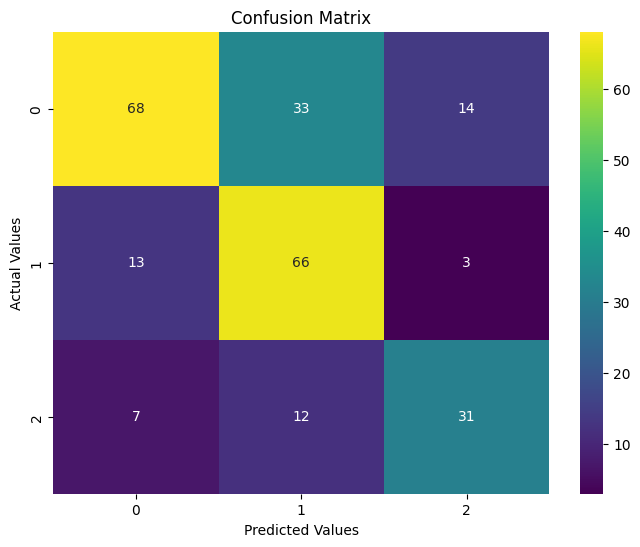

In [48]:
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

In [53]:
x_train_full = train_df.drop(columns=['id', 'outcome', 'target'])
y_train_full = train_df['target'].values

x_train_full_list = [x_train_full[col].values for col in x_train_full.columns]

In [54]:
def get_model_inputs(df, cat_cols, num_cols):
    inputs = [df[col].values for col in cat_cols]
    inputs.append(df[num_cols].values)
    return inputs


x_train_full_list = get_model_inputs(x_train_full, cat_cols, num_cols)

In [55]:
early_stop = EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)

In [56]:
history_full = model.fit(
    x=x_train_full_list,
    y=y_train_full,
    epochs=100, 
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6847 - loss: 0.7658
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7029 - loss: 0.7260
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7082 - loss: 0.6815
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6859 - loss: 0.7251
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7297 - loss: 0.6577
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6861 - loss: 0.6987
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7066 - loss: 0.6900
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7336 - loss: 0.6578
Epoch 9/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7263 - loss: 0.6820
Epoch 10/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7298 - loss: 0.6893
Epoch 11/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7101 - loss: 0.6750
Epoch 12/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

In [57]:
x_test_list = get_model_inputs(test_df, cat_cols, num_cols)

In [59]:
test_preds_probs = model.predict(x_test_list)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [60]:
test_preds = np.argmax(test_preds_probs, axis=1)

In [61]:
reverse_mapping = {0: 'lived', 1: 'died', 2: 'euthanized'}
final_predictions = [reverse_mapping[p] for p in test_preds]

In [62]:
submission = pd.DataFrame({'id': test_df['id'], 'outcome': final_predictions})
submission.to_csv('submission.csv', index=False)

In [63]:
submission

,id,outcome
0,1235,lived
1,1236,died
2,1237,lived
3,1238,euthanized
4,1239,lived
...,...,...
819,2054,died
820,2055,euthanized
821,2056,lived
822,2057,lived


In [64]:
model.save('Horse_DL.keras')

In [65]:
with open('horse_ordinal_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
